# AI-Based Health Prediction System
This notebook includes data loading, EDA, ML model training, and prediction logic for Task 1.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import sqlite3

In [6]:
# Load Dataset
df = pd.read_csv('alzheimers_disease_data.csv')

# Display first rows
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [7]:
# Dataset Information
print(df.shape)
print(df.info())
print(df.isnull().sum())

(2149, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-n

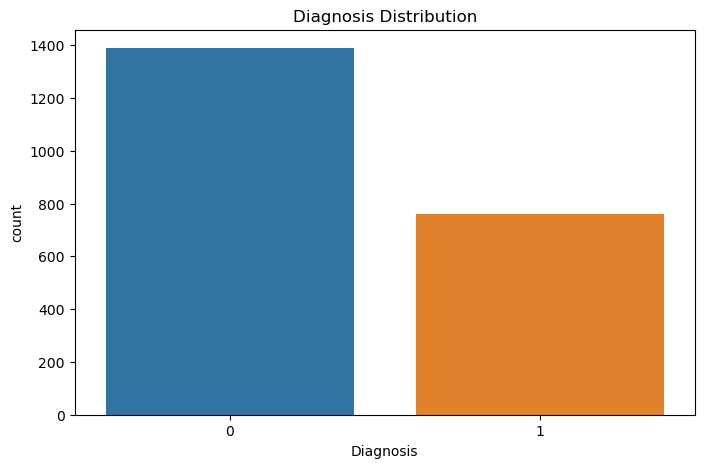

In [9]:
# Data Visualization
plt.figure(figsize=(8,5))
sns.countplot(x='Diagnosis', data=df)
plt.title('Diagnosis Distribution')
plt.show()

In [10]:
# Feature Selection
X = df[['Age', 'BMI', 'CholesterolTotal', 'PhysicalActivity',
        'MemoryComplaints', 'Forgetfulness']]

y = df['Diagnosis']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [12]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Train Model
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [14]:
# Prediction
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7186046511627907


In [18]:
conn = sqlite3.connect("patients.db")
c = conn.cursor()

c.execute('''
CREATE TABLE IF NOT EXISTS patients(
id INTEGER PRIMARY KEY AUTOINCREMENT,
name TEXT,
dob TEXT,
email TEXT,
glucose REAL,
haemoglobin REAL,
cholesterol REAL,
remarks TEXT
)
''')

conn.commit()

In [19]:
st.title("Health Prediction App")

name = st.text_input("Full Name")
dob = st.date_input("Date of Birth")
email = st.text_input("Email")
glucose = st.number_input("Glucose")
haemoglobin = st.number_input("Haemoglobin")
cholesterol = st.number_input("Cholesterol")

2026-05-28 12:29:41.640 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:29:42.524 
  command:

    streamlit run C:\Users\nutan\anaconda3\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-28 12:29:42.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:29:42.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:29:42.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:29:42.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:29:42.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:29:42.545 Thread 'MainThread': mi

## Simple Health Prediction Logic

In [20]:
def health_prediction(glucose, haemoglobin, cholesterol):

    if glucose > 140:
        return "Possible Diabetes Risk"

    elif cholesterol > 240:
        return "Possible Heart Disease Risk"

    elif haemoglobin < 12:
        return "Possible Anemia Risk"

    else:
        return "Healthy"

# Example
print(health_prediction(150, 11, 260))

Possible Diabetes Risk


In [21]:
data = pd.read_sql("SELECT * FROM patients", conn)

st.dataframe(data)

2026-05-28 12:30:15.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:30:15.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 12:30:15.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()